## Set Up

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sys
sys.path.append('../src')
from utils import set_plot_style

set_plot_style()

## Load Data

In [2]:
df = pd.read_csv('../data/raw/used_car_sales.csv')
df.head()

,ID,Distributor Name,Location,Car Name,Manufacturer Name,Car Type,Color,Gearbox,Number of Seats,Number of Doors,...,Purchased Date,Car Sale Status,Sold Date,Purchased Price-$,Sold Price-$,Margin-%,Sales Agent Name,Sales Rating,Sales Commission-$,Feedback
0,O2KE17,Carmudi,California,Fortuner,Toyota,SUV,Gray,Automatic,8,5,...,2022-10-26,Un Sold,1970-01-01,8296,0,0,Pranav,1,0,Average
1,EPMPC8,Carousell,Philadelphia,Creta,Hyundai,Hatchback,Blue,Automatic,5,5,...,2017-08-25,Sold,2021-03-03,5659,4770,-16,Vihaan,5,0,Good
2,SQKXAP,Carsome,North Carolina,Scorpio,Mahindra,SUV,Gray,Automatic,5,5,...,2018-06-13,Un Sold,1970-01-01,8430,0,0,Aarush,4,0,Good
3,PWP2QK,Trivett,North Carolina,Plato,Prazo,Convertible,Gray,Automatic,2,2,...,2023-05-14,Sold,2024-04-02,6919,7942,15,Anushka,1,205,Average
4,FNDDKM,Zupps,Portland,Dzire,Maruti,Sedan,Red,Automatic,5,5,...,2022-08-24,Un Sold,1970-01-01,6864,0,0,Pavan,3,0,Poor


## 1. Column Overview
Spot inconsistent naming (`Price-$`, `Engine Power-HP`) and any junk columns.

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 25 columns):
 #   Column              Non-Null Count  Dtype
---  ------              --------------  -----
 0   ID                  10000 non-null  str  
 1   Distributor Name    10000 non-null  str  
 2   Location            10000 non-null  str  
 3   Car Name            10000 non-null  str  
 4   Manufacturer Name   10000 non-null  str  
 5   Car Type            10000 non-null  str  
 6   Color               10000 non-null  str  
 7   Gearbox             10000 non-null  str  
 8   Number of Seats     10000 non-null  int64
 9   Number of Doors     10000 non-null  int64
 10  Energy              10000 non-null  str  
 11  Manufactured Year   10000 non-null  int64
 12  Price-$             10000 non-null  int64
 13  Mileage-KM          10000 non-null  int64
 14  Engine Power-HP     10000 non-null  int64
 15  Purchased Date      10000 non-null  str  
 16  Car Sale Status     10000 non-null  str  
 17  Sold 

## 2. Missing Value

In [16]:
df.isnull().sum()

ID                    0
Distributor Name      0
Location              0
Car Name              0
Manufacturer Name     0
Car Type              0
Color                 0
Gearbox               0
Number of Seats       0
Number of Doors       0
Energy                0
Manufactured Year     0
Price-$               0
Mileage-KM            0
Engine Power-HP       0
Purchased Date        0
Car Sale Status       0
Sold Date             0
Purchased Price-$     0
Sold Price-$          0
Margin-%              0
Sales Agent Name      0
Sales Rating          0
Sales Commission-$    0
Feedback              0
dtype: int64

## 3. Duplicate / Suspicious Columns


In [13]:
df.duplicated().sum()

np.int64(0)

## 4. Outlier Detection (price, mileage)

<Axes: xlabel='Mileage-KM'>

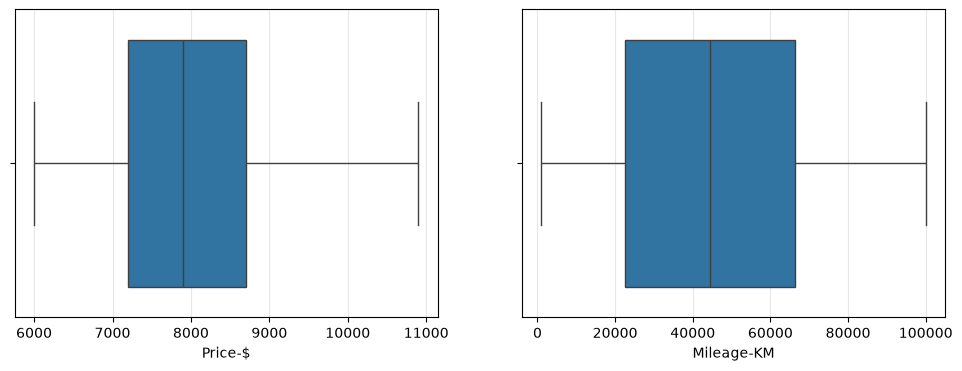

In [14]:
fig, ax = plt.subplots(1, 2, figsize=(12,4))
sns.boxplot(x=df['Price-$'], ax=ax[0])
sns.boxplot(x=df['Mileage-KM'], ax=ax[1])

## 5. Correlation Matrix (numeric features)

<Axes: >

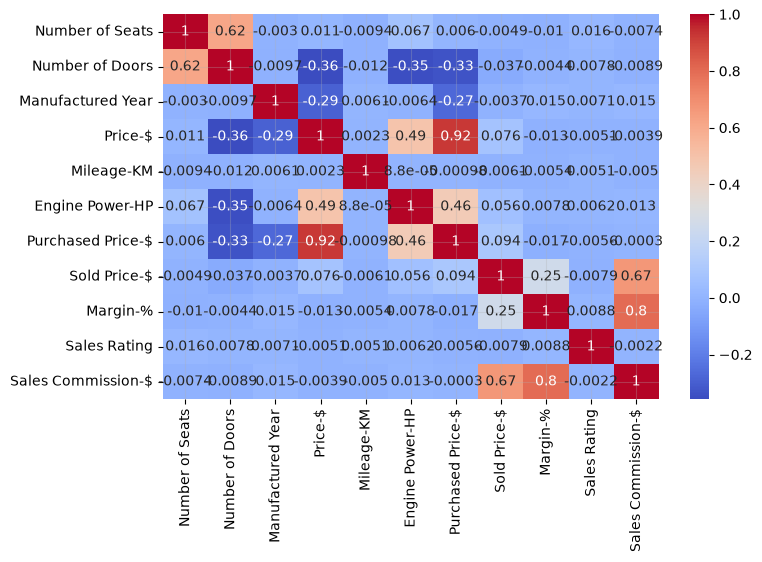

In [ ]:
import numpy as np

numeric_df = df.select_dtypes(include='number').drop(columns=['ID'], errors='ignore')
corr = numeric_df.corr()

plt.figure(figsize=(12, 8))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(
    corr,
    mask=mask,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    vmin=-1,
    vmax=1,
    linewidths=0.5,
    cbar_kws={'shrink': 0.8}
)
plt.title('Correlation Matrix of Numeric Features')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()


## 6. Categorical vs. Price

([0, 1, 2, 3],
 [Text(0, 0, 'Hybrid'),
  Text(1, 0, 'Petrol'),
  Text(2, 0, 'Electric'),
  Text(3, 0, 'Diesel')])

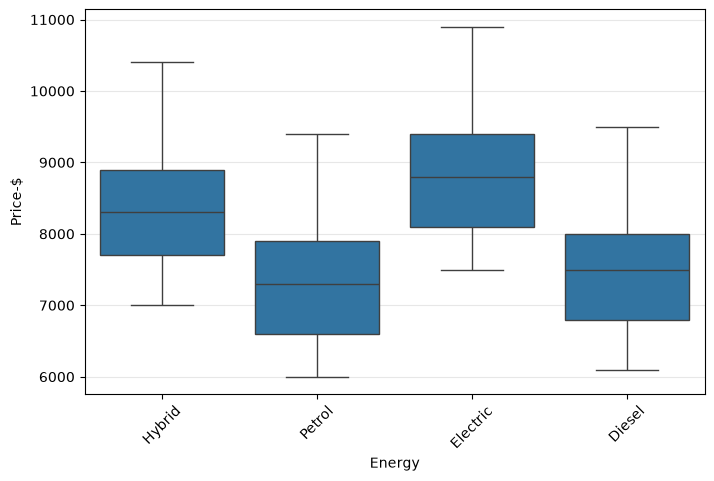

In [20]:
sns.boxplot(data=df, x='Energy', y='Price-$')
plt.xticks(rotation=45)